In [ ]:
##Feature Engineering on Student Dataset
    #Author:Alekhya Banerjee
    #Tools:Python,Pandas,Numpy,Matplotlib,Seaborn
    #Domain:Data Preprocessing / Machine Learning Foundations
    #Objective:To clean and prepare raw student data for machine learning by handling missing values and encoding categorical variables-
                #covering missing value heatmap analysis,nominal encoding,ordinal encoding and label encoding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('Student_data_analysis.csv')
data

,Age,Education_Level,Skill_Level,Internship_Experience,Gender,Preferred_Job_Role,CGPA,Projects_Count,Study_Hours_Per_Day,Placement
0,21,Bachelor's,Advanced,NaN,Male,Data Scientist,7.58,2,4.4,No
1,22,PhD,Intermediate,Short,Male,Data Scientist,NaN,2,3.6,No
2,25,Master's,Intermediate,Long,Male,ML Engineer,6.88,3,4.6,No
3,21,Bachelor's,Advanced,Medium,Male,Data Scientist,7.91,7,4.6,Yes
4,27,Diploma,Advanced,Medium,Male,Data Scientist,6.92,1,4.6,No
...,...,...,...,...,...,...,...,...,...,...
495,26,Bachelor's,Beginner,Medium,Female,Software Developer,6.45,2,4.2,No
496,29,Bachelor's,Advanced,Medium,Female,Software Developer,8.60,2,5.7,No
497,24,High School,Beginner,Short,Male,Business Analyst,8.57,2,4.7,No
498,23,PhD,Expert,Short,Male,ML Engineer,6.42,2,6.6,Yes


In [3]:
data.sample(5)

,Age,Education_Level,Skill_Level,Internship_Experience,Gender,Preferred_Job_Role,CGPA,Projects_Count,Study_Hours_Per_Day,Placement
301,26,Bachelor's,Beginner,Long,Female,Software Developer,9.17,1,4.2,Yes
18,20,Bachelor's,Expert,Long,Male,Data Analyst,6.96,1,5.6,No
355,25,Bachelor's,Intermediate,Long,Male,Data Analyst,7.33,3,3.7,No
326,22,Bachelor's,Intermediate,NaN,Male,Business Analyst,8.09,3,6.4,No
379,26,Bachelor's,Intermediate,Short,Female,Business Analyst,8.47,2,6.2,No


In [4]:
data.shape

(500, 10)

--UNDERSTANDING THE DATASET--

In [5]:
data.columns

Index(['Age', 'Education_Level', 'Skill_Level', 'Internship_Experience',
       'Gender', 'Preferred_Job_Role', 'CGPA', 'Projects_Count',
       'Study_Hours_Per_Day', 'Placement'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Education_Level        498 non-null    object 
 2   Skill_Level            498 non-null    object 
 3   Internship_Experience  332 non-null    object 
 4   Gender                 498 non-null    object 
 5   Preferred_Job_Role     498 non-null    object 
 6   CGPA                   498 non-null    float64
 7   Projects_Count         500 non-null    int64  
 8   Study_Hours_Per_Day    500 non-null    float64
 9   Placement              500 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [7]:
data.select_dtypes(include='object')

,Education_Level,Skill_Level,Internship_Experience,Gender,Preferred_Job_Role,Placement
0,Bachelor's,Advanced,NaN,Male,Data Scientist,No
1,PhD,Intermediate,Short,Male,Data Scientist,No
2,Master's,Intermediate,Long,Male,ML Engineer,No
3,Bachelor's,Advanced,Medium,Male,Data Scientist,Yes
4,Diploma,Advanced,Medium,Male,Data Scientist,No
...,...,...,...,...,...,...
495,Bachelor's,Beginner,Medium,Female,Software Developer,No
496,Bachelor's,Advanced,Medium,Female,Software Developer,No
497,High School,Beginner,Short,Male,Business Analyst,No
498,PhD,Expert,Short,Male,ML Engineer,Yes


In [8]:
#Checking for categorical values
for col in data.select_dtypes(include='object'):
    print('\n',col)
    print(data[col].value_counts(dropna=False)) #dropna=False->displays the missing values 


 Education_Level
Education_Level
Bachelor's     221
Master's       133
Diploma         66
High School     48
PhD             30
NaN              2
Name: count, dtype: int64

 Skill_Level
Skill_Level
Intermediate    219
Advanced        144
Beginner        100
Expert           35
NaN               2
Name: count, dtype: int64

 Internship_Experience
Internship_Experience
NaN       168
Medium    152
Short     106
Long       74
Name: count, dtype: int64

 Gender
Gender
Male      272
Female    211
Other      15
NaN         2
Name: count, dtype: int64

 Preferred_Job_Role
Preferred_Job_Role
Software Developer    149
Data Analyst          113
Data Scientist         90
Business Analyst       79
ML Engineer            67
NaN                     2
Name: count, dtype: int64

 Placement
Placement
No     338
Yes    162
Name: count, dtype: int64


In [9]:
#Checking for duplicate rows
duplicates=data.duplicated().sum()
print('Duplicates present =',duplicates)

Duplicates present = 0


In [10]:
#Checking for missing values
data.isnull().sum()

Age                        0
Education_Level            2
Skill_Level                2
Internship_Experience    168
Gender                     2
Preferred_Job_Role         2
CGPA                       2
Projects_Count             0
Study_Hours_Per_Day        0
Placement                  0
dtype: int64

In [11]:
#percentage of missing values
(data.isnull().sum()/len(data))*100

Age                       0.0
Education_Level           0.4
Skill_Level               0.4
Internship_Experience    33.6
Gender                    0.4
Preferred_Job_Role        0.4
CGPA                      0.4
Projects_Count            0.0
Study_Hours_Per_Day       0.0
Placement                 0.0
dtype: float64

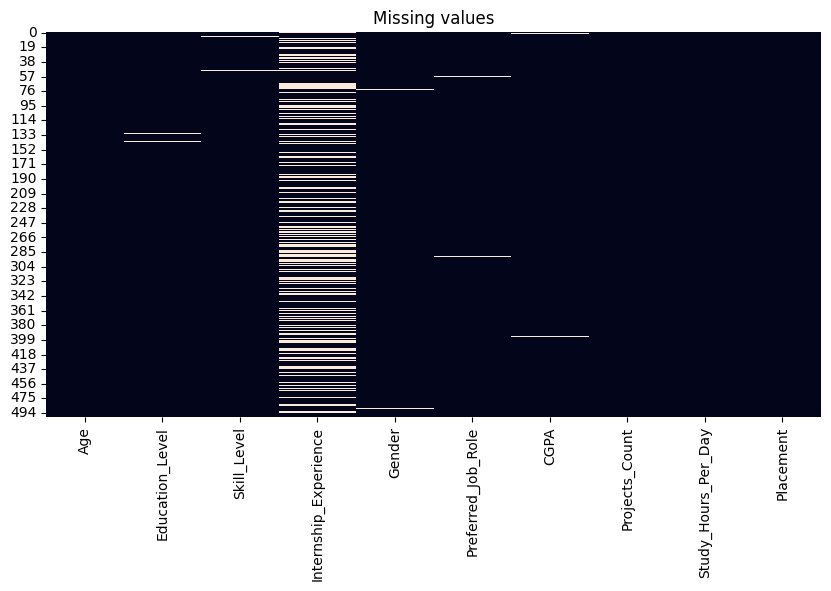

In [12]:
#Visualisation using a heatmap
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(),cbar=False)
plt.title("Missing values")
plt.show()

--PREPROCESSING--

In [13]:
#Handling missing values
categorical_cols=['Education_Level','Skill_Level','Gender','Preferred_Job_Role']
for col in categorical_cols:
    data[col]=data[col].fillna(data[col].mode()[0]) #mode()->returns the most frequently occurring value in that column

In [14]:
data['Internship_Experience']=data['Internship_Experience'].fillna('Unknown')
#'Internship_Experience' has a lot of missing values so it can't be filled with mode

In [15]:
data['CGPA']=data['CGPA'].fillna(data['CGPA'].median())

In [16]:
data.isnull().sum()

Age                      0
Education_Level          0
Skill_Level              0
Internship_Experience    0
Gender                   0
Preferred_Job_Role       0
CGPA                     0
Projects_Count           0
Study_Hours_Per_Day      0
Placement                0
dtype: int64

--IDENTIFYING TWO TYPES OF CATEGORICAL VARIABLES--

In [17]:
#Ordinal Variables
    #Education_Level-> High School < Diploma < Bachelor's < Master's < PhD
    #Skill_Level-> Beginner < Intermediate < Advanced < Expert
    #Intership_Experience-> None < Short < Medium < Long

In [18]:
##These variables have categories with a meaningful order.Therefore,Ordinal Encoding is appropriate

In [19]:
ordinal_cols=['Education_Level','Skill_Level']

In [20]:
#Nominal Variables
    #Gender
    #Preferred_Job_Role

In [21]:
##These variables do not have any ranking.Therefore,One-Hot Encoding is appropriate

In [22]:
nominal_cols=['Gender','Preferred_Job_Role']

--SEPERATE FEATURES AND TARGET--

In [23]:
X=data.drop('Placement',axis=1) #drop the placement column and take everything else
Y=data['Placement']

In [24]:
X

,Age,Education_Level,Skill_Level,Internship_Experience,Gender,Preferred_Job_Role,CGPA,Projects_Count,Study_Hours_Per_Day
0,21,Bachelor's,Advanced,Unknown,Male,Data Scientist,7.580,2,4.4
1,22,PhD,Intermediate,Short,Male,Data Scientist,7.675,2,3.6
2,25,Master's,Intermediate,Long,Male,ML Engineer,6.880,3,4.6
3,21,Bachelor's,Advanced,Medium,Male,Data Scientist,7.910,7,4.6
4,27,Diploma,Advanced,Medium,Male,Data Scientist,6.920,1,4.6
...,...,...,...,...,...,...,...,...,...
495,26,Bachelor's,Beginner,Medium,Female,Software Developer,6.450,2,4.2
496,29,Bachelor's,Advanced,Medium,Female,Software Developer,8.600,2,5.7
497,24,High School,Beginner,Short,Male,Business Analyst,8.570,2,4.7
498,23,PhD,Expert,Short,Male,ML Engineer,6.420,2,6.6


In [25]:
Y

0       No
1       No
2       No
3      Yes
4       No
      ... 
495     No
496     No
497     No
498    Yes
499     No
Name: Placement, Length: 500, dtype: object

--TRAIN_TEST_SPLIT--

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [28]:
X_train.shape

(400, 9)

In [29]:
X_test.shape

(100, 9)

--ORDINAL CODING--

In [30]:
from sklearn.preprocessing import OrdinalEncoder

In [31]:
oe=OrdinalEncoder(categories=[["High School","Diploma","Bachelor's","Master's","PhD"],["Beginner","Intermediate","Advanced","Expert"]])

In [33]:
oe.fit(X_train[ordinal_cols]) #learning the encoding rules from X_train

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['High School', 'Diploma', ...], ['Beginner', 'Intermediate', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
Name,Type,Value
categories_ categories_: list of arraysThe categories of each feature determined during ``fit`` (in order ofthe features in X and corresponding with the output of ``transform``).This does not include categories that weren't seen during ``fit``.,list,"[array(['High ... dtype=object), array(['Begin... dtype=object)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Education_Level','Skill_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 1.0,int,2


In [34]:
oe.categories_ #inspecting

[array(['High School', 'Diploma', "Bachelor's", "Master's", 'PhD'],
       dtype=object),
 array(['Beginner', 'Intermediate', 'Advanced', 'Expert'], dtype=object)]

In [35]:
#Transforming the Training data
X_train[ordinal_cols]=oe.transform(X_train[ordinal_cols])

In [36]:
X_train[ordinal_cols].head()

,Education_Level,Skill_Level
249,3.0,2.0
433,1.0,1.0
19,2.0,0.0
322,2.0,1.0
332,0.0,0.0


In [37]:
#Transforming the Test data
X_test[ordinal_cols]=oe.transform(X_test[ordinal_cols])

In [38]:
X_test[ordinal_cols].head()

,Education_Level,Skill_Level
361,2.0,1.0
73,3.0,2.0
374,0.0,0.0
155,2.0,0.0
104,3.0,0.0


--ENCODING THE COLUMN "Internship_Experience"--

In [63]:
mapping={'Unknown':-1,'None':0,'Short':1,'Medium':2,'Long':3}
#Unknown is not actually an ordered category so mapping is done manually

In [65]:
X_train['Internship_Experience']=X_train['Internship_Experience'].map(mapping)

In [67]:
X_train['Internship_Experience']

249    2
433    2
19    -1
322    3
332   -1
      ..
106    1
270    2
348    3
435   -1
102    3
Name: Internship_Experience, Length: 400, dtype: int64

--NOMINAL ENCODING--

In [39]:
nominal_cols=['Gender','Preferred_Job_Role']

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
ohe=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [42]:
#Fitting
ohe.fit(X_train[nominal_cols])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [52]:
#Transform Train Data
train_encoded=ohe.transform(X_train[nominal_cols])
train_encoded

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(400, 8))

In [56]:
#Transform Test Data
test_encoded=ohe.transform(X_test[nominal_cols])
test_encoded[0:5]

array([[1., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0.]])

In [46]:
#Converting One-Hot output to Dataframes

In [48]:
encoded_columns=ohe.get_feature_names_out(nominal_cols) #getting the column names
encoded_columns

array(['Gender_Female', 'Gender_Male', 'Gender_Other',
       'Preferred_Job_Role_Business Analyst',
       'Preferred_Job_Role_Data Analyst',
       'Preferred_Job_Role_Data Scientist',
       'Preferred_Job_Role_ML Engineer',
       'Preferred_Job_Role_Software Developer'], dtype=object)

In [51]:
train_encoded_df=pd.DataFrame(train_encoded,columns=encoded_columns,index=X_train.index)
train_encoded_df #nominal encoded dataframe on training data created

,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
249,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
433,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
322,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
106,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
270,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
348,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [55]:
test_encoded_df=pd.DataFrame(test_encoded,columns=encoded_columns,index=X_test.index)
test_encoded_df ##nominal encoded dataframe on test data created

,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
361,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
73,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
374,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
155,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
104,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
347,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
86,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
438,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [57]:
#Removing orginal nominal columns
X_train=X_train.drop(nominal_cols,axis=1)
X_test=X_test.drop(nominal_cols,axis=1)

In [58]:
#Combining the One Hot Columns
X_train=pd.concat([X_train,train_encoded_df],axis=1)
X_train

,Age,Education_Level,Skill_Level,Internship_Experience,CGPA,Projects_Count,Study_Hours_Per_Day,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
249,24,3.0,2.0,Medium,5.77,4,8.4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
433,21,1.0,1.0,Medium,8.16,4,5.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,24,2.0,0.0,Unknown,7.06,5,5.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
322,27,2.0,1.0,Long,7.60,6,4.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332,26,0.0,0.0,Unknown,7.99,3,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,23,2.0,1.0,Short,5.45,2,4.5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
270,23,3.0,0.0,Medium,6.69,0,4.7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
348,25,2.0,1.0,Long,7.93,5,5.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,26,3.0,1.0,Unknown,8.08,4,7.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [59]:
X_test=pd.concat([X_test,test_encoded_df],axis=1)
X_test

,Age,Education_Level,Skill_Level,Internship_Experience,CGPA,Projects_Count,Study_Hours_Per_Day,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
361,30,2.0,1.0,Unknown,8.45,2,6.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
73,24,3.0,2.0,Unknown,6.05,5,4.7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
374,29,0.0,0.0,Unknown,7.43,3,2.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
155,27,2.0,0.0,Medium,8.07,3,3.3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
104,23,3.0,0.0,Long,8.17,3,5.7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,30,0.0,3.0,Short,7.72,3,6.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
86,26,3.0,0.0,Medium,7.63,1,2.2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
75,26,3.0,3.0,Short,7.81,2,4.3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
438,27,3.0,0.0,Unknown,6.75,2,6.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [60]:
#X_train and X_test contain Numerical Features + Ordinal encoded features + One-Hot encoded Features

--LABEL ENCODING--

In [65]:
#Handling target(Output) column->Placement
from sklearn.preprocessing import LabelEncoder

In [66]:
le=LabelEncoder()

In [67]:
#Fit and transform training target
Y_train=le.fit_transform(Y_train)

In [68]:
#transform test target
Y_test=le.transform(Y_test)

In [69]:
le.classes_ #inspecting

array(['No', 'Yes'], dtype=object)

In [70]:
Y_train[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

--CHECKING FINAL ENCODED DATA--

In [71]:
X_train.head()

,Age,Education_Level,Skill_Level,Internship_Experience,CGPA,Projects_Count,Study_Hours_Per_Day,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
249,24,3.0,2.0,Medium,5.77,4,8.4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
433,21,1.0,1.0,Medium,8.16,4,5.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,24,2.0,0.0,Unknown,7.06,5,5.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
322,27,2.0,1.0,Long,7.60,6,4.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332,26,0.0,0.0,Unknown,7.99,3,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [72]:
X_test.head()

,Age,Education_Level,Skill_Level,Internship_Experience,CGPA,Projects_Count,Study_Hours_Per_Day,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
361,30,2.0,1.0,Unknown,8.45,2,6.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
73,24,3.0,2.0,Unknown,6.05,5,4.7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
374,29,0.0,0.0,Unknown,7.43,3,2.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
155,27,2.0,0.0,Medium,8.07,3,3.3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
104,23,3.0,0.0,Long,8.17,3,5.7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [73]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 249 to 102
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    400 non-null    int64  
 1   Education_Level                        400 non-null    float64
 2   Skill_Level                            400 non-null    float64
 3   Internship_Experience                  400 non-null    object 
 4   CGPA                                   400 non-null    float64
 5   Projects_Count                         400 non-null    int64  
 6   Study_Hours_Per_Day                    400 non-null    float64
 7   Gender_Female                          400 non-null    float64
 8   Gender_Male                            400 non-null    float64
 9   Gender_Other                           400 non-null    float64
 10  Preferred_Job_Role_Business Analyst    400 non-null    float64
 11  Preferred

In [78]:
#Before
data.iloc[:,0:9]

,Age,Education_Level,Skill_Level,Internship_Experience,Gender,Preferred_Job_Role,CGPA,Projects_Count,Study_Hours_Per_Day
0,21,Bachelor's,Advanced,Unknown,Male,Data Scientist,7.580,2,4.4
1,22,PhD,Intermediate,Short,Male,Data Scientist,7.675,2,3.6
2,25,Master's,Intermediate,Long,Male,ML Engineer,6.880,3,4.6
3,21,Bachelor's,Advanced,Medium,Male,Data Scientist,7.910,7,4.6
4,27,Diploma,Advanced,Medium,Male,Data Scientist,6.920,1,4.6
...,...,...,...,...,...,...,...,...,...
495,26,Bachelor's,Beginner,Medium,Female,Software Developer,6.450,2,4.2
496,29,Bachelor's,Advanced,Medium,Female,Software Developer,8.600,2,5.7
497,24,High School,Beginner,Short,Male,Business Analyst,8.570,2,4.7
498,23,PhD,Expert,Short,Male,ML Engineer,6.420,2,6.6


In [77]:
#After
X_train

,Age,Education_Level,Skill_Level,Internship_Experience,CGPA,Projects_Count,Study_Hours_Per_Day,Gender_Female,Gender_Male,Gender_Other,Preferred_Job_Role_Business Analyst,Preferred_Job_Role_Data Analyst,Preferred_Job_Role_Data Scientist,Preferred_Job_Role_ML Engineer,Preferred_Job_Role_Software Developer
249,24,3.0,2.0,Medium,5.77,4,8.4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
433,21,1.0,1.0,Medium,8.16,4,5.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19,24,2.0,0.0,Unknown,7.06,5,5.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
322,27,2.0,1.0,Long,7.60,6,4.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332,26,0.0,0.0,Unknown,7.99,3,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,23,2.0,1.0,Short,5.45,2,4.5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
270,23,3.0,0.0,Medium,6.69,0,4.7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
348,25,2.0,1.0,Long,7.93,5,5.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
435,26,3.0,1.0,Unknown,8.08,4,7.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Conclusion

In this project, I explored and implemented different techniques for handling categorical data in a student placement dataset.

### Key Learnings

- **Ordinal Encoding** was used for `Education_Level`, `Skill_Level`, and `Internship_Experience` because these variables contain categories with a meaningful order.
- **One-Hot Encoding** was used for `Gender` and `Preferred_Job_Role` because their categories do not have any inherent order.
- **Label Encoding** was used for the `Placement` target variable to convert `No` and `Yes` into numerical values.
- The dataset was divided into training and testing sets before encoding to avoid **data leakage**.
- The encoders were **fitted only on the training data** and then used to transform both the training and testing data.
- Missing values were handled before the encoding process, with `Unknown` used for missing `Internship_Experience` values.
- The final dataset contains numerical features that are suitable for use in machine learning algorithms.

### Final Takeaway

Different types of categorical variables require different encoding strategies. Understanding whether a variable is ordinal or nominal is important for choosing the appropriate encoding technique. This project helped me understand not only how to perform categorical encoding using Scikit-learn, but also how to apply it correctly within an ML preprocessing workflow without introducing data leakage.